## Introduction
Convolutional neural networks (CNNs) are widely used for image classification tasks, but their internal decision-making process is often difficult to interpret. To better understand how these models make predictions, interpretability methods can be applied.

In this assignment, a pre-trained ResNet18 model is used together with LayerCAM to visualize class activation maps. These maps highlight which regions of an image contribute most to the model’s prediction. The objective is to analyze how the model behaves for different classes (animals) by comparing activation maps for both positive and negative examples.

## Method
A pre-trained ResNet18 model with ImageNet weights was used for this assignment. The corresponding preprocessing transformations were applied to each input image before inference.
For each selected class, two images were analyzed: one positive example containing the target object and one negative example where the object is absent. Each image was passed through the network to obtain prediction probabilities using a softmax function.
The predicted class was obtained by selecting the highest probability and converting it to a class label using the ImageNet index.
To interpret the model’s decision, LayerCAM was applied to the final convolutional layer of the network. This produced activation maps indicating which regions of the image contributed most to the prediction.
Finally, the activation maps were overlaid on the original images to visualize and compare the model’s focus for the positive and negative examples.

## Results

In [5]:
import functions as fn

base_path = 'Images'
class_index_path = 'imagenet_class_index.json'

model, preprocess = fn.load_model()
classes = fn.get_classes(base_path)

classes

['Kangaroo', 'Leopard', 'Rottweiler']

### Class 1 - Kangaroo

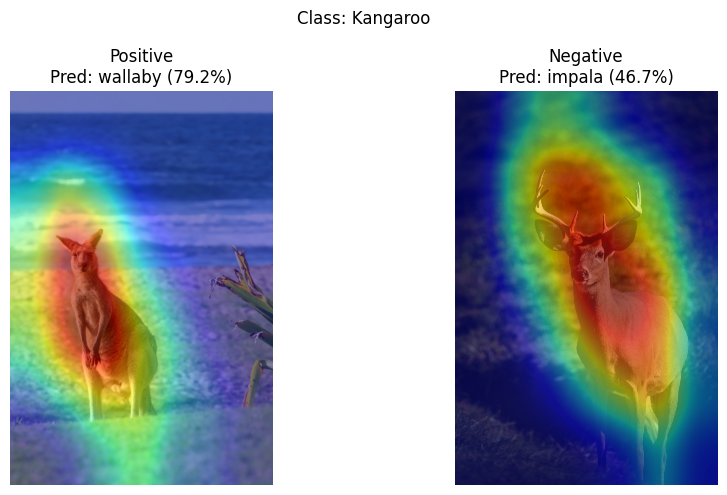

In [6]:
positive, negative = fn.analyze_class(
    model,
    preprocess,
    'Images/Kangaroo',
    class_index_path
)
fn.plot_class_results(positive, negative, 'Kangaroo')

Positive sample: <br>The model predicts wallaby with a confidence of 79.2%. The activation map highlights the central region of the animal, particularly the upper part of the body. 

Negative sample: <br>The model predicts impala with a confidence of 46.7%. The activation map again focuses on the upper part of the body.

### Class 2 - Leopard

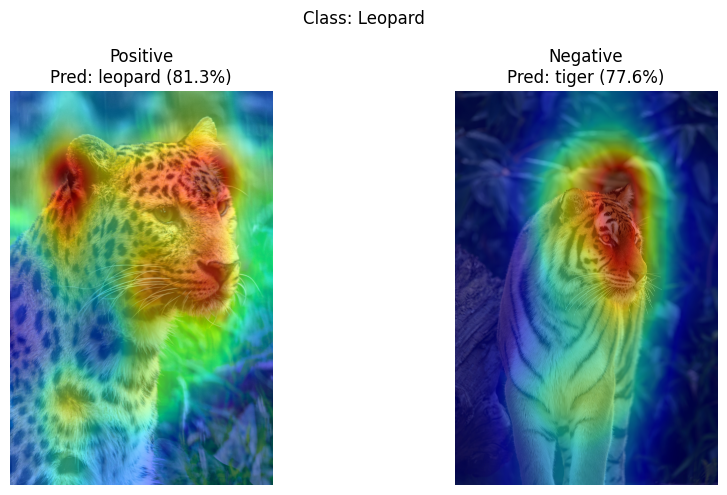

In [7]:
positive, negative = fn.analyze_class(
    model,
    preprocess,
    'Images/Leopard',
    class_index_path
)
fn.plot_class_results(positive, negative, 'Leopard')

Positive sample: <br>The model predicts leopard with a confidence of 81.3%. The activation map highlights the head region, particularly around the eyes and face, with strong intensity. Additional activation is visible across parts of the body, but the highest concentration is focused on the facial features.

Negative sample: <br>The model predicts tiger with a confidence of 77.6%. The activation map is primarily concentrated around the head and upper body of the animal. Compared to the positive sample, the activation appears slightly more localized to the face and slightly a bit over the face, with less spread across the rest of the body.

### Class 3 - Rottweiler

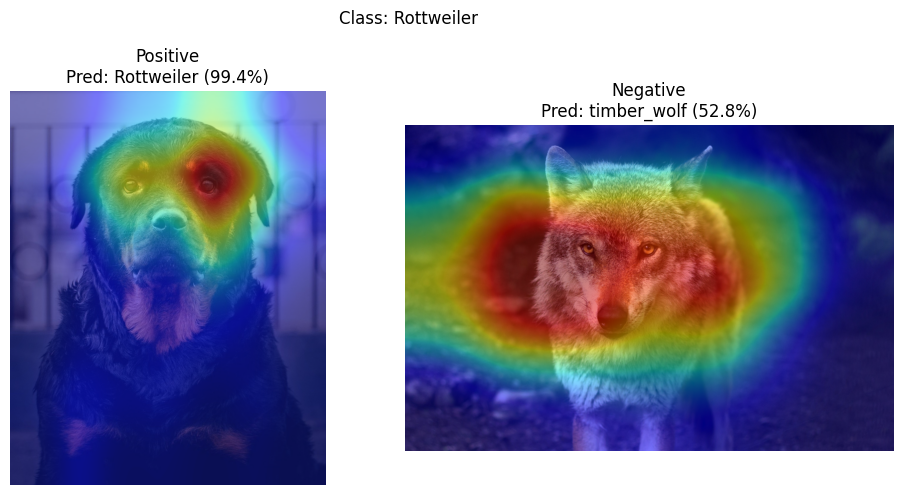

In [8]:
positive, negative = fn.analyze_class(
    model,
    preprocess,
    'Images/Rottweiler',
    class_index_path
)
fn.plot_class_results(positive, negative, 'Rottweiler')

Positive sample: <br>The model predicts Rottweiler with a confidence of 99.4%. The activation map is strongly concentrated around the head, particularly near the eyes and facial region. The rest of the body shows significantly lower activation, indicating that the model focuses primarily on facial features.

Negative sample: <br>The model predicts timber wolf with a confidence of 52.8%. The activation map is more spread out compared to the positive sample, covering a larger portion of the animal’s body. The highest activation is still located around the head, but noticeable activation extends across the torso as well.

## Discussion

The activation maps show that the model mainly focuses on the most informative parts of the animal, most often the head or upper body. These regions appear to contain the key visual features used for classification.
The results also indicate that the model often predicts classes that are visually similar to the target, such as kangaroo and wallaby or leopard and tiger. In these cases, the activation maps highlights similar regions, suggesting that the model relies on shared visual features. This makes it difficult to distinguish between closely related classes.
For the negative examples, the activation is generally more spread out, which may reflect greater uncertainty. Despite this, the model still focuses on relevant parts of the image rather than the background.
Overall, the model appears to rely on meaningful visual patterns, but has difficulty making clear distinctions between similar classes.